In [1]:
#wave analysis and make raster plots of AN network  Fig3 C 

from multiprocessing import Pool, Array, Manager
import traceback
import os
import sys
import matplotlib.pyplot as plt
from scipy import integrate
import traceback
from tqdm import tqdm

import math
from scipy.signal import find_peaks
from scipy.signal import periodogram
from scipy import signal
import scipy

import pickle


from collections import deque
import itertools
import numpy as np
import pandas as pd

fs = 20
fs_l = 15

In [3]:
import os
import sys

sys.path.append('../')
sys.path.append('../anmodel')
import matplotlib.pyplot as plt

import anmodel

import pickle


OK
OK


In [15]:

fs=30
fs_l=25


fs=30
fs_l=25


class eval_wave:
    def __init__(self,model, date_i,NE,NI,con_M,con_M_in,con_ex_ex,con_ex_in,con_in_ex, con_in_in,T, Tp, dt,con_log, drc, fig_dir,exs, ex_diff):
        manager = Manager()
        
        self.date_i = date_i
        self.N = NE + NI
        self.NE = NE
        self.NI = NI
        self.exs = exs
        self.ex_diff = ex_diff
        self.tbs = int(T/Tp)
        self.con_M = con_M
        self.con_ex_ex = con_ex_ex
        self.con_ex_in = con_ex_in
        self.con_in_ex = con_in_ex
        self.con_M_in = con_M_in
        self.con_in_in=con_in_in
       
        self.T = T
        self.Tp=Tp
        self.dt = dt

        self.drc = drc
        
   
        self.x = np.arange(0, T, dt)/1000

        self.df_np = manager.Array('d', range(len(exs)*14))
        
        if con_log == "True":
            self.savef = fig_dir+"{}_{}_NE{}_NI{}_conM{}_SD{}_conMin{}_inSD{}_T{}_dt{}".format(model, self.date_i, self.NE,self.NI,self.con_M,self.con_ex_ex,self.con_M_in, self.con_in_in,self.T,self.dt)
        else:
            self.savef = fig_dir+"{}_{}_NE{}_NI{}_conth{}_{}_{}_{}_T{}_dt{}".format(model, self.date_i, self.NE,self.NI,self.con_ex_ex,self.con_ex_in,self.con_in_ex, self.con_in_in,self.T,self.dt)
    
    def array_short(self, a, size):
        length = a.shape[0]
        b=np.zeros(a.shape[0]//size) #+a.shape[0]%size

        for i in range(b.shape[0]):
            ts = i*size
            te = (i+1)*size
            if  te+1 < a.shape[0]:
                v = np.mean(a[ts:te+1])
#             print(v)
            b[i]=v
        return b
    
    def graph_saving(self, exs, pdf_save = False, graph=True, sh=False):
        if pdf_save ==True:
            pdf = PdfPages(self.savef+".pdf")
            
        for num, ex in enumerate(exs):
            if type(ex) != str:
                ex = round(ex,2)
                ex_in = round((ex + self.ex_diff), 2)
            else:
                ex_in = float(ex) +self.ex_diff
                ex_in = f"{ex_in:,.2f}"


            print("exp", ex)
            
#             sp_c_li = []
            for n in range(self.N):
                try:
                    for tb in range(self.tbs):
                        v_file = self.drc+ "ex"+str(ex)+"_"+"ex_in"+str(ex_in)+"_"+"N"+str(n)+"_"+str(tb)+".bin" 
                        f2= open(v_file, "rb")
                        rectype = np.dtype(np.float64)
                        v_tb = np.fromfile(f2, dtype=rectype).astype("float32")
                        if tb==0:
                            v=v_tb
                        else:
                            v=np.append(v, v_tb).astype("float32")
                        f2.close()
                    
#                     pattern, maxfre, sp_c, peak_np = self.fre_spike(v[int(v_off/self.dt):int(T/self.dt)], int(T-v_off), self.dt)
                    if sh ==True:
                            v=self.array_short(v, size=10000).astype("float32")
                    if graph==True:
                        if self.N > 60 and self.N < 200:
                            if n%10 ==0:
                                plt.figure(figsize=(15, 4))
                                plt.title("Neuron{}".format(n))
                                if sh ==True:
                                    plt.plot(v) 
                                else: 
                                    plt.plot(self.x,v)   #time[0:int(T/dt)-1],
                                
                                plt.ylim(-100, 40)
                                plt.xlabel('Time (sec)',fontsize = fs)
                        #             plt.xlim(0,2)
                                    #plt.ylim(0,1)
                                plt.xticks(fontsize = fs)
                                plt.yticks(fontsize = fs)

                                plt.show()
                                # print("max_fre", maxfre)
                                # print("sp_num", sp_c)
                                # print(pattern)
                        elif self.N > 200:
                            if n%25 ==0:
                                plt.figure(figsize=(15, 4))
                                plt.title("Neuron{}".format(n))
                                if sh ==True:
                                    plt.plot(v) 
                                else: 
                                    plt.plot(self.x,v) 
                                plt.ylim(-100, 40)
                                plt.xlabel('Time (sec)',fontsize = fs)
                        #             plt.xlim(0,2)
                                    #plt.ylim(0,1)
                                plt.xticks(fontsize = fs)
                                plt.yticks(fontsize = fs)

                                plt.show()
                                # print("max_fre", maxfre)
                                # print("sp_num", sp_c)
                                # print(pattern)
                        else:
                            if n%6 ==0:
                                plt.figure(figsize=(15, 4))
                                plt.title("Neuron{}".format(n))
                                if sh ==True:
                                    plt.plot(v) 
                                else: 
                                    plt.plot(self.x,v) 
                                plt.ylim(-100, 40)
                                plt.xlabel('Time (sec)',fontsize = fs)
                        #             plt.xlim(0,2)
                                    #plt.ylim(0,1)
                                plt.xticks(fontsize = fs)
                                plt.yticks(fontsize = fs)

                                plt.show()
#                             print("max_fre", maxfre)
#                             print("sp_num", sp_c)
#                             print(pattern)

                    if pdf_save ==True:
                        if self.NE+self.NI > 60 and self.NE+self.NI < 200:
                            if n%10 ==0:
                                fig, axes = plt.subplots(figsize=(20, 8))
                                axes.set_title("param {}\n ex {}, Neuron{}".format(self.date_i, ex, n))
                                axes.plot(self.x,v)   #time[0:int(T/dt)-1],
                                axes.set_xlabel('Time (sec)')
                                axes.set_ylim(-110,40)
                                axes.set_rasterized(True)
                                pdf.savefig(fig)
                                plt.close()

                        elif self.NE+self.NI> 200:
                            if n%25 ==0:
                                fig, axes = plt.subplots(figsize=(20, 8))
                                axes.set_title("param {}\n ex {}, Neuron{}".format(self.date_i, ex, n))
                                axes.plot(self.x,v)   #time[0:int(T/dt)-1],
                                axes.set_xlabel('Time (sec)')
                                axes.set_ylim(-110,40)
                                axes.set_rasterized(True)
                                pdf.savefig(fig)
                                plt.close()
                        else:
                            fig, axes = plt.subplots(figsize=(20, 8))
                            axes.set_title("param {}\n ex {}, Neuron{}".format(self.date_i, ex, n))
                            axes.plot(self.x,v)   #time[0:int(T/dt)-1],
                            axes.set_xlabel('Time (sec)')
                            axes.set_ylim(-110,40)
                            axes.set_rasterized(True)
                            pdf.savefig(fig)
                            plt.close()
                except:
                    traceback.print_exc()
        if pdf_save ==True:
            pdf.close()
        print("pdf_saving_end")
        
        
    def multi_cal(self, cores, exs, cv_w, moving, v_off,  T_w="None",  raster=False):
        args = []
        if T_w == "None":
            T = self.T
        else:
            T = T_w
            
        
        for num, ex in enumerate(exs):
            args.append((num, ex, T, cv_w, moving, v_off, raster))
        print(f'analyze networks: using {cores} cores')
        with Pool(processes=cores) as pool:
            pool.map(self.calc_values, args)
            
    
    def calc_values(self, args):
        num, ex, T, cv_w, moving, v_off,  raster = args
        if type(ex) != str:
            ex = round(ex,2)
            ex_in = round((ex + self.ex_diff), 2)
        else:
            ex_in = float(ex) +self.ex_diff
            ex_in = f"{ex_in:,.2f}"
        flag=0
        
        self.df_np[num*14]=float(ex)
        
        v_file = self.drc+ "ex"+str(ex)+"_"+"ex_in"+str(ex_in)+"_"+"N"+str(0)+"_"+str(0)+".bin" 
        f2= open(v_file, "rb")
        rectype = np.dtype(np.float64)
        v_tb = np.fromfile(f2, dtype=rectype).astype("float32")
        dt = round(self.Tp/len(v_tb),4)
        print("ex{} dt{}".format(ex, dt))

        if type(ex) != str:
            ex = round(ex,2)
            ex_in = round((ex + self.ex_diff), 2)
        else:
            ex_in = float(ex) +self.ex_diff
            ex_in = f"{ex_in:,.2f}"
        flag=0
#             pattern_li = []
#             pattern_id=[]
        wake_c = 0
        sleep_c = 0
        wake_ex_c =0
        sleep_ex_c=0
        

        print("analyze exp", ex)
        
#             sp_c_li = []
        sp_fre_li = np.zeros(self.N)
        spts = np.zeros((self.N, int((T-v_off)/dt)), dtype = "int8")
        for n in range(self.N):
            try:
                for tb in range(self.tbs):
                    v_file = self.drc+ "ex"+str(ex)+"_"+"ex_in"+str(ex_in)+"_"+"N"+str(n)+"_"+str(tb)+".bin" 
                    f2= open(v_file, "rb")
                    rectype = np.dtype(np.float64)
                    v_tb = np.fromfile(f2, dtype=rectype).astype("float32")
                    if tb==0:
                        v=v_tb
                    else:
                        v=np.append(v, v_tb)
                    f2.close()

                    
                pattern, maxfre, sp_c, peak_np = self.fre_spike(v[int(v_off/dt):int(T/dt)], int(T-v_off), dt)
                
                if np.any(np.isinf(v)) or np.any(np.isnan(v)):
                    flag = 1
                    print("nan_Error, can't make DF")
                    self.df_np[num*14+0]=1
#                     self.df_np[num][1:] = -1
                    for i in range(12):
#                         if i==0:
#                             continue
                        self.df_np[num*14 +i+2] = -1
                    break  #N
                
                if flag==1:
                    continue

                if pattern == "SWS" or pattern == "SWS_HIGH_FR":
                    sleep_c+=1
                    if n<self.NE:
                        sleep_ex_c+=1
                if pattern == "AWAKE" or pattern == "AWAKE_HIGH_FR":
                    wake_c+=1
                    if n<self.NE:
                        wake_ex_c+=1

#                     pattern_li.append(pattern)
                sp_fre_li[n]=(sp_c/(T-v_off)*1000)

                try:
                    if maxfre!=0 and sp_c!=0:
                        if pattern!= "ERROR" and pattern != "EXCLUDED": 
                        # if pattern == "SWS" or pattern == "SWS_HIGH_FR" or pattern == "AWAKE" or pattern == "AWAKE_HIGH_FR" or pattern == "SWS_FEW_SPIKES" or pattern == "RES":
                            spts[n]= peak_np
        #                                                             print("{}, sp_add".format(n))
#                                     pattern_id.append(n)
                except:
                    print("file_Error, cant make DF")
                    traceback.print_exc()
                    flag = 1
                    self.df_np[num*14+1]=2
                    for i in range(12):
#                         if i==0:
#                             continue
                        self.df_np[num*14 +i+2] = -1
                    break  #N end
            except:
                print("file_Error, cant make DF")
                traceback.print_exc()
                flag=1
                self.df_np[num*14+1]=2
                for i in range(12):
#                         if i==0:
#                             continue
                        self.df_np[num*14 +i+2] = -1
                break  #N end
            
        if raster == True:
            plt.figure(figsize=(23, 8))
            Lt = int((T-v_off)/dt)
            x2=  np.arange(0, T-v_off, dt)
            for i in range(spts.shape[0]):
                t_sp = x2[spts[i, :] > 0.5]   # spike times
                plt.plot(t_sp/1000, i*np.ones(len(t_sp)), '.',
                        ms=8, markeredgewidth=0.1, color ="black")
            plt.title("{}_N{}_ex{}".format(self.date_i, self.N, ex))
           
            plt.xlabel('Time (sec)',fontsize = fs)
            plt.xlim(1.0, 3.0)
            plt.ylabel('Neuron ID', fontsize = fs)
            #plt.xlim(0, 1)
            plt.xticks(fontsize = fs_l)
            plt.yticks(fontsize = fs_l)
            plt.show()
            
            #article
            plt.figure(figsize=(23, 8))
            Lt = int((T-v_off)/dt)
            x2=  np.arange(0, T-v_off, dt)
            for i in range(spts.shape[0]):
                t_sp = x2[spts[i, :] > 0.5]   # spike times
                plt.plot(t_sp/1000, i*np.ones(len(t_sp)), '.',
                        ms=8, markeredgewidth=0.1, color ="magenta")
#        
            plt.xlabel('',fontsize = fs)
            plt.xlim(3.0, 5.0)
            plt.ylabel('', fontsize = fs)

            ax = plt.gca()
            ax.axes.xaxis.set_ticklabels([])
            ax.axes.yaxis.set_ticklabels([])

            ax.spines['right'].set_visible(False)
            ax.spines['top'].set_visible(False)
            
            
            plt.grid(False)

            plt.savefig("rater_net_{}_N{}_ex{}_M.SVG".format(self.date_i, self.N, ex))
            plt.show()
            
                
        if flag!=1 :
            m_sp_fre =np.mean(sp_fre_li)
            var_sp_fre =np.var(sp_fre_li)
            m_sp_fre_ex =np.mean(sp_fre_li[0:self.NE])
            var_sp_fre_ex =np.var(sp_fre_li[0:self.NE])
            sleep_per = sleep_c/(self.N)*100
            wake_per = wake_c/(self.N)*100
            sleep_per_ex = sleep_ex_c/(self.NE)*100
            wake_per_ex = wake_ex_c/(self.NE)*100

            self.df_np[num*14+1] = 0  #%nan
            self.df_np[num*14+2] = sleep_per
            self.df_np[num*14+3] = wake_per
            self.df_np[num*14+4] = m_sp_fre
            self.df_np[num*14+5] = var_sp_fre
            self.df_np[num*14+8] = sleep_per_ex
            self.df_np[num*14+9] = wake_per_ex
            self.df_np[num*14+10] = m_sp_fre_ex
            self.df_np[num*14+11] = var_sp_fre_ex
  

            sps_cv = self.calc_cv(self.N,spts, T-v_off, cv_w,  moving, dt)
#             print("CV_sp_count/w", sps_cv)
            self.df_np[num*14+6] = sps_cv
            sps_cv_ex = self.calc_cv(self.NE,spts, T-v_off, cv_w,  moving, dt)
            # print("CV_sp_count_ex/w", sps_cv_ex)
            self.df_np[num*14+12] = sps_cv_ex
            

            self.df_np[num*14+7] = -1
            self.df_np[num*14+13] = -1


    def get_cv_pv(self, cv):
        if cv >= np.max(self.cv_dis_all):
            pv = 0
        else:
            minx = np.argmin(np.abs(self.cv_dis_all-cv))

            low_p = minx/len(self.cv_dis_all)*100
            up_p = (len(self.cv_dis_all)-minx)/len(self.cv_dis_all)*100
            if low_p<up_p:
                pv=low_p
                # print(low_p)
            else:
                pv=up_p
                # print(up_p)
            print("p_value", pv)
        return pv
        
    def make_df(self):
        df_np = np.array(self.df_np).reshape(len(self.exs), 14)
#         exs = np.array(self.exs).reshape(-1,1)
        print(df_np.shape)
#         print(exs)
#         df_np = np.concatenate([exs, self.df_np], axis=1)
        df_cc = pd.DataFrame(df_np, columns=["exp","%nan","%sleep","%wake","mean_spike_fre","var_spike_fre",  "cv", "p", "%sleep_ex","%wake_ex","mean_spike_fre_ex","var_spike_fre_ex", "cv_ex", "p_ex"])
        # df_cc.to_excel(self.drc + "cc.xlsx")
        df_cc.to_excel(self.savef + "_cc.xlsx")
        print(df_cc)
        nan_exs = df_cc[df_cc["%nan"]==1]["exp"]
        nan_exs = nan_exs.tolist()
        print(("nan_exp: {}\n".format(nan_exs)))
        error_exs = df_cc[df_cc["%nan"]==2]["exp"]
        error_exs = error_exs.tolist()
        print(("error_exp: {}\n".format(error_exs)))          

        return df_cc
            
            
    def calc_cv(self, N, spts, T, cv_w,  moving, dt):
        wc = int((T-cv_w)/moving+1)
        sp_li = []
        for m in range(wc):
            if m*moving/dt>0 and m*moving/dt + cv_w/dt  < (T)/dt:
                sp_sum = np.sum(spts[0:N,int(m*moving/dt):int(m*moving/dt + cv_w/dt)])
                sp_li.append(sp_sum)
        if np.mean(sp_li)!=0:
            sps_cv = np.var(sp_li)/np.mean(sp_li)
        else:
            sps_cv =0
        print("CV_sp_count/w", sps_cv)
        return sps_cv
    
    def fre_spike(self, v, T, dt):
    
        if np.any(np.isinf(v)) or np.any(np.isnan(v)):
            print("fre_spike: nan")
            return "Excluded",0, 0, np.zeros(int(T/dt), dtype="int8")
        else:
#             wavech =WaveCheck(1000)
#             pattern = wavech.pattern(v, T, dt, pr=False)
            detv: np.ndarray = signal.detrend(v)
            max_potential: float = max(detv)
            f: np.ndarray  # Array of sample frequencies
            spw: np.ndarray  # Array of power spectral density or power spectrum
            f, spw = periodogram(detv, fs=1/dt*1000)
            maxamp: float = max(spw)
            nummax: int = spw.tolist().index(maxamp)
            maxfre: float = f[nummax]


            peaks = find_peaks(v, height=-20)[0]
    #         print(peaks)
            peak_np = np.zeros(int(T/dt), dtype="int8")
            peak_np[peaks]=1
            return "sleep", maxfre, len(peaks), peak_np

exs ['-0.30']
analyze networks: using 4 cores
ex-0.30 dt0.02
analyze exp -0.30


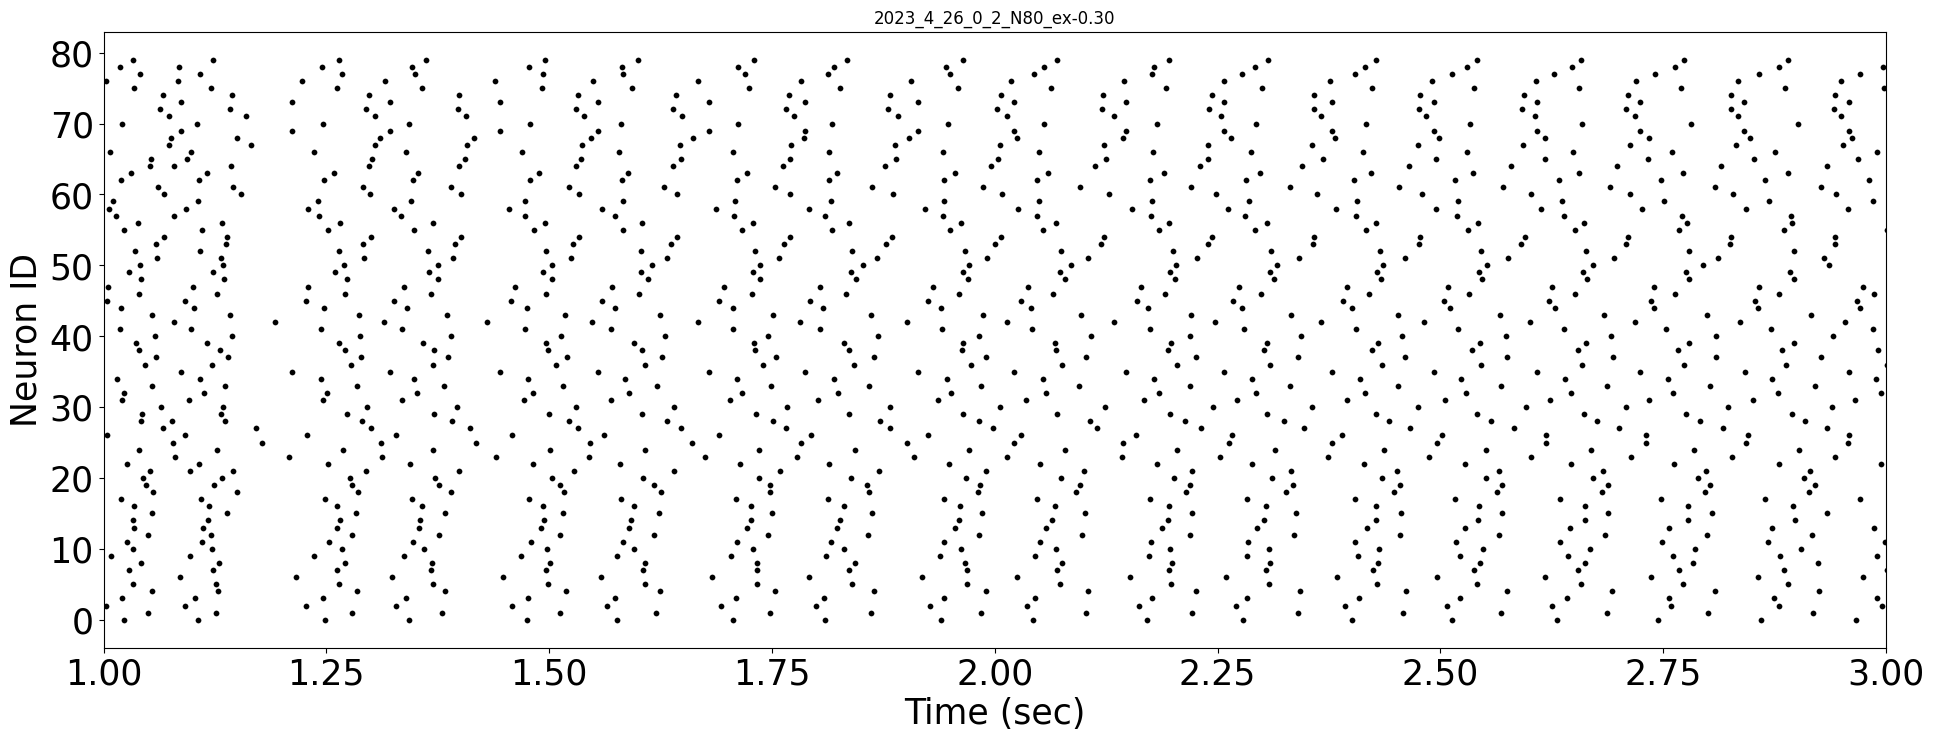

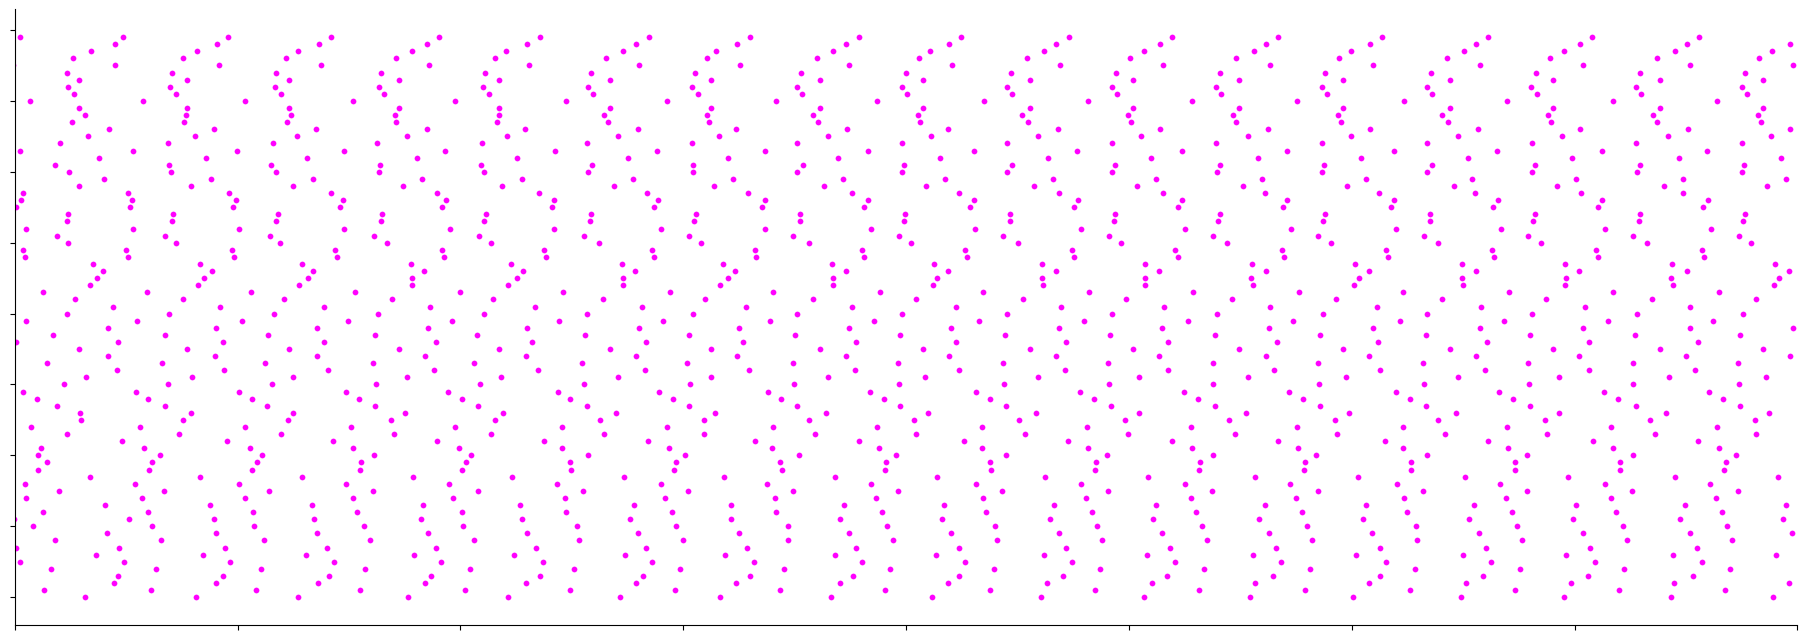

CV_sp_count/w 2.9102255639097745
CV_sp_count/w 2.883651954757806


In [16]:
# evaluate wave form from C++ + CUDA
###copy to next
import traceback

rdir = "../AN_network/"
model_pre = "AN"
model_op="_net_bifurcation"
date_i = "2023_4_26_0_2"              

bifur ="_nmdar"


NEs = [64]
Ips = [20]
g_nap_SDs = [0]
con_Ms =[1.0]   
con_M_ins=[1.0]
con_ex_exs = [0.01]  #ex to ex  #conSD
con_ex_ins = [0.01]  #ex to in 
con_in_ins = [0.01]    #conSDin
con_in_exs = [0.01]
T = 5000 #ms
Tps= [1000]
# raster_T = 10000 #
dt = 0.02
exp_ini = -2.0
exp_last = 2.0
exp_step = 0.5

th_num= 1
exp_ex = 0.5
exp_in = 0.5
init = "r"
seed = 4
con_log = True
scaling = False
sh=True

# T_raster = 1000 #ms
cores=4
v_off = 0 #ms
T_w = 5000#"None" # None analyze in whole time   raster
cv_w = 50 #ms
moving = 50 #ms 

raster = True
calc = True
graph = False
pdf_save = False

# stat = False
# ISI_M_r = [0.6, 3.8]
# counts = 100 # * 10000 samples  ~100

exs = [-0.3]

fs = 25
nowdir = os.getcwd()

model_name = model_pre+model_op + bifur

par_f_dir = rdir + "/con_cu_i/"+ model_name + "/param_"+date_i+"/"
time = np.arange(0, T , dt)/1000 #s
    


exs = [f"{ex:,.2f}" for ex in exs]
for n, i in enumerate(exs):
    if i =="-0.00":
        exs[n] = "0.00"
print("exs", exs)
ex_diff= exp_in -exp_ex


for (NE,Tp) in zip(NEs, Tps):
    tbs=int(T/Tp)
    for Ip in Ips:
        NI = int(NE*Ip/(100-Ip))
        for (con_M, con_M_in) in zip(con_Ms, con_M_ins):

                for (con_ex_ex, con_ex_in) in zip(con_ex_exs, con_ex_ins):
 
                    for (con_in_ex, con_in_in) in zip(con_in_exs, con_in_ins):

                              
                           
                           
                            drc =rdir +"con_cu_i/{}/param_{}/NE{}_NI{}/conM{}_conSD{}_conMin{}_conSDin{}/seed_{}/init_{}/T_{}/Tp_{}/".format(model_name, date_i, NE, NI,con_M, con_ex_ex,con_M_in, con_in_in, seed, init, T, Tp)
                           
                            wave_check = eval_wave(model_name, date_i,NE,NI,con_M,con_M_in,con_ex_ex,con_ex_in,con_in_ex, con_in_in, T, Tp, dt,str(con_log),drc, par_f_dir, exs, ex_diff)



                            if calc==True:
                                wave_check.multi_cal(cores, exs, cv_w, moving, v_off,  T_w,   raster)
#                                              
                            if pdf_save ==True or graph ==True:
                                wave_check.graph_saving(exys, pdf_save, graph, sh)
                                            
    

